In [1]:
# importing essential library 
import joblib 
import pandas  as pd  # pandas is for reading and manipulation 
import matplotlib.pyplot as plt  #  Basic graphs banata hai.
import seaborn as sns  # Stylish aur professional graphs banata hai (Matplotlib ke upar based).

from sklearn.preprocessing import LabelEncoder
# importing train-test split
from sklearn.model_selection import train_test_split 

# Scaling import form sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression   
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report  
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm       import SVC 
from sklearn.model_selection import GridSearchCV


from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
print("All libraries imported successfully ✅")


All libraries imported successfully ✅


In [2]:
import sys
print(sys.executable)

c:\Users\prade\OneDrive\Desktop\Hospital_Model\venv\Scripts\python.exe


# Loading Dataset

In [3]:

# Load Dataset 
df = pd.read_csv('Dataset/ORIGINAL_HealthcareServiceQuality_Merged.csv')



In [4]:
print(df.head())



   Gender    Age   Hospital Type                  Visit Type  \
0    Male  15-25      Government   Follow-up/Routine Checkup   
1  Female  15-25         Private  OPD (Doctor Consultation )   
2  Female  15-25  Private clinic  OPD (Doctor Consultation )   
3    Male  25-35  Private clinic  OPD (Doctor Consultation )   
4    Male  15-25  Private clinic  OPD (Doctor Consultation )   

           Waiting Time Nurse Staff Behaviour Doctor Communication  \
0         30-60 minutes               Neutral                Agree   
1         15-30 minutes     Strongly Disagree    Strongly Disagree   
2  Less than 15 minutes        Strongly Agree       Strongly Agree   
3         15-30 minutes                 Agree       Strongly Agree   
4         15-30 minutes                 Agree       Strongly Agree   

  Hospital Cleanliness  Overall Satisfaction  Return Intention  ...  \
0             Disagree                     4                 3  ...   
1    Strongly Disagree                     3        

# Shape,describe

In [5]:
#print(df.info())
#print(df.describe())
print(df.shape)    # 


(308, 23)


#Checking null values and fill them with mode 

In [6]:
print(df.isnull().sum()) 

Gender                           0
Age                              0
Hospital Type                    0
Visit Type                       0
Waiting Time                     0
Nurse Staff Behaviour            0
Doctor Communication             0
Hospital Cleanliness             0
Overall Satisfaction             0
Return Intention                 0
Biggest Problem                 30
Recommendation                   0
Treatment Quality                0
Waiting Area Facilities          0
Respect Privacy                  0
Medicine Explanation             0
Charges                          0
Occupation                       0
Age1                             0
Nurse Staff Behaviour Score      0
Hospital Cleanliness Score       0
Overall_satisfaction_Avergae     0
Waiting Time Number              0
dtype: int64


In [7]:
# Use mode for categorical column
df['Biggest Problem'].mode()
print(df["Biggest Problem"].value_counts())  

Biggest Problem
Long lines             124
Short consultation      71
Cost                    57
Rude staff behavior     26
Name: count, dtype: int64


In [8]:
#Fill null values with mode
df["Biggest Problem"] = df["Biggest Problem"].fillna(
    df["Biggest Problem"].mode()[0]
)

In [9]:
# Remomve null value in Biggest problem
print(df.isnull().sum())

Gender                          0
Age                             0
Hospital Type                   0
Visit Type                      0
Waiting Time                    0
Nurse Staff Behaviour           0
Doctor Communication            0
Hospital Cleanliness            0
Overall Satisfaction            0
Return Intention                0
Biggest Problem                 0
Recommendation                  0
Treatment Quality               0
Waiting Area Facilities         0
Respect Privacy                 0
Medicine Explanation            0
Charges                         0
Occupation                      0
Age1                            0
Nurse Staff Behaviour Score     0
Hospital Cleanliness Score      0
Overall_satisfaction_Avergae    0
Waiting Time Number             0
dtype: int64


# Check inconsistency in categorical columns

In [10]:
for col in df.select_dtypes(include="object"):
    print(f"\n===== {col} =====")
    print(df[col].value_counts())  


===== Gender =====
Gender
Male      184
Female    124
Name: count, dtype: int64

===== Age =====
Age
15-25    264
25-35     41
35-45      3
Name: count, dtype: int64

===== Hospital Type =====
Hospital Type
Private           148
Government         95
Private clinic     65
Name: count, dtype: int64

===== Visit Type =====
Visit Type
OPD (Doctor Consultation )            190
Follow-up/Routine Checkup              71
In-Patient (Admitted/Hospitalized)     31
Emergency                              16
Name: count, dtype: int64

===== Waiting Time =====
Waiting Time
15-30 minutes           142
Less than 15 minutes    105
30-60 minutes            51
More than 1 hour         10
Name: count, dtype: int64

===== Nurse Staff Behaviour =====
Nurse Staff Behaviour
Neutral              126
Agree                114
Strongly Agree        41
Strongly Disagree     16
Disagree              11
Name: count, dtype: int64

===== Doctor Communication =====
Doctor Communication
Agree                126
Strong

C:\Users\prade\AppData\Local\Temp\ipykernel_2884\997996863.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


# EDA : Exploratory Data analysis  / Univariate Analysis : Ek time pr ek he code analyze

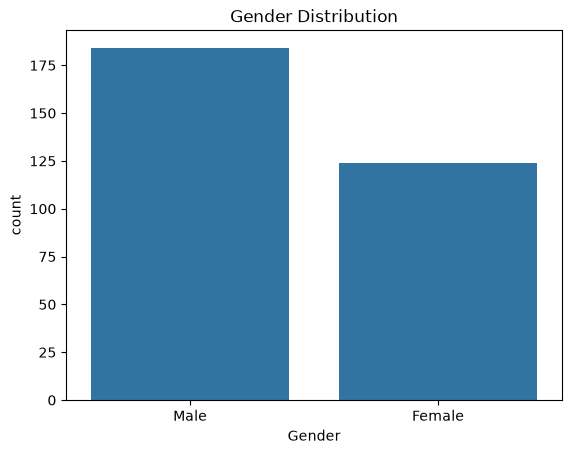

In [12]:
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")

plt.show()

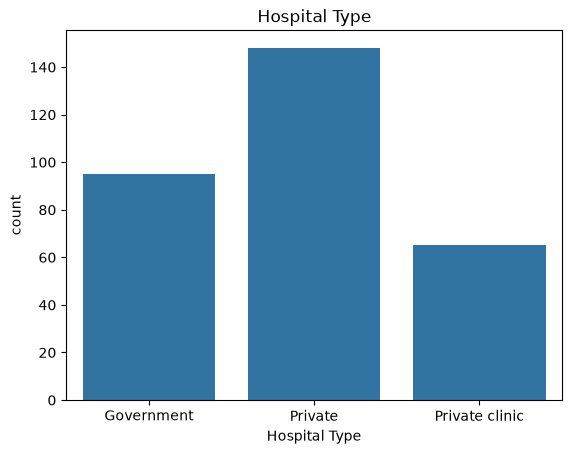

In [13]:
# Hospital Type 
sns.countplot(x="Hospital Type", data=df)
plt.title("Hospital Type")
plt.show()

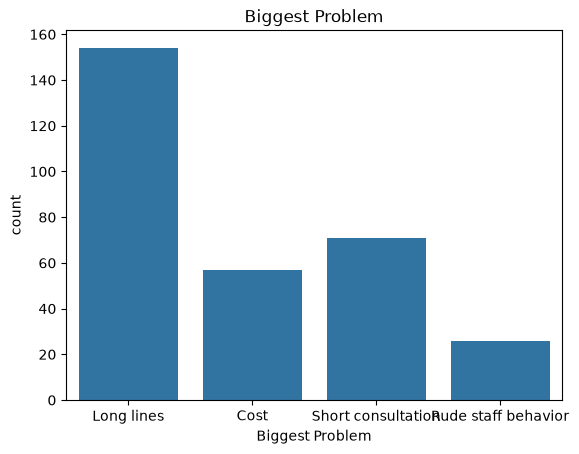

In [14]:
# Biggest problem 
sns.countplot(x="Biggest Problem", data=df)
plt.title("Biggest Problem")
plt.show()

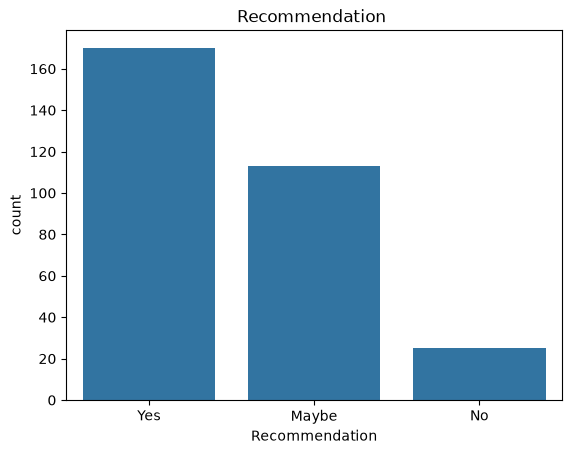

In [15]:
# Recommendation 
sns.countplot(x="Recommendation", data=df)
plt.title("Recommendation ")
plt.show()

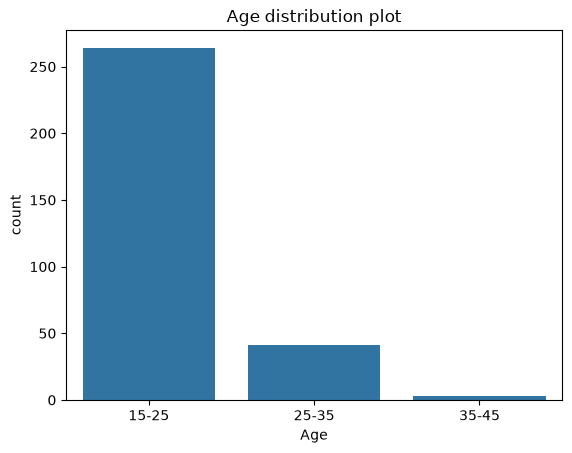

In [16]:
#Age distribution plot
sns.countplot(x="Age", data=df)
plt.title("Age distribution plot")
plt.show()

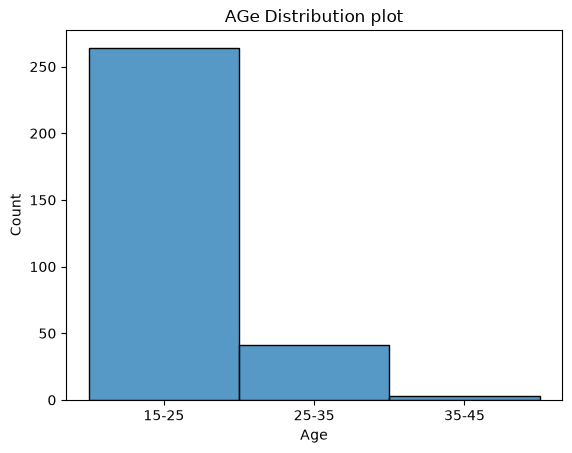

In [17]:
#ge Histogram
sns.histplot(x="Age", data=df )
plt.title("AGe Distribution plot")
plt.show()

# Bivariate Analysis : Checking relationship between two varaibles

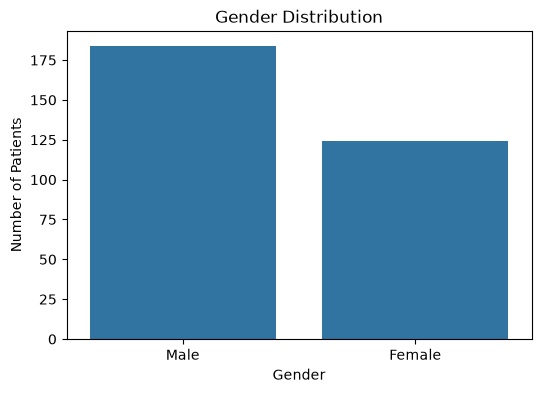

In [18]:
# Gender

plt.figure(figsize=(6,4))
sns.countplot(x="Gender",data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

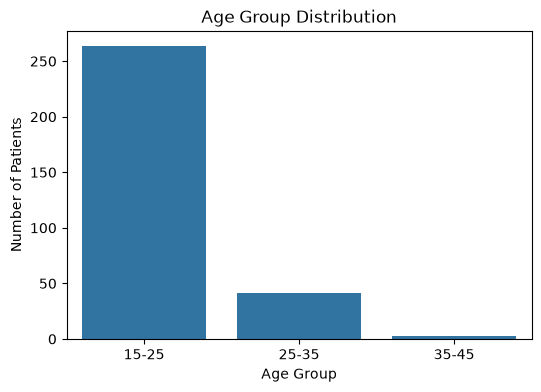

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x="Age", data=df)
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.show()

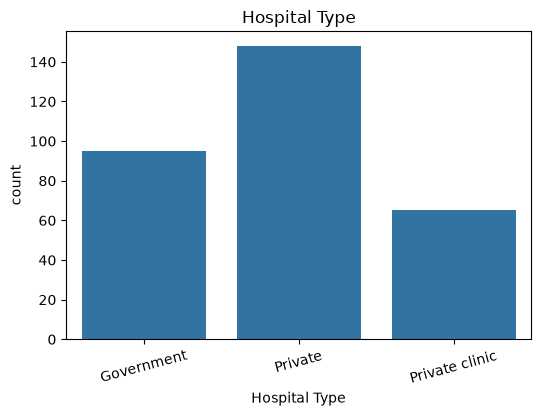

In [20]:
# Hospital Type 
plt.figure(figsize=(6,4))

sns.countplot(x="Hospital Type", data=df)
plt.title("Hospital Type")
plt.xticks(rotation=15)
plt.show()

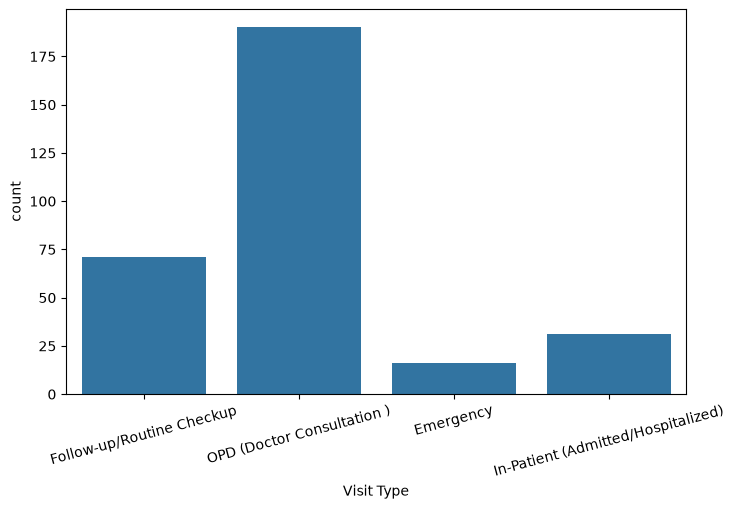

In [21]:
# Visit Type

plt.figure(figsize=(8,5))
sns.countplot(x="Visit Type", data=df)
plt.xticks(rotation=15)
plt.show() 

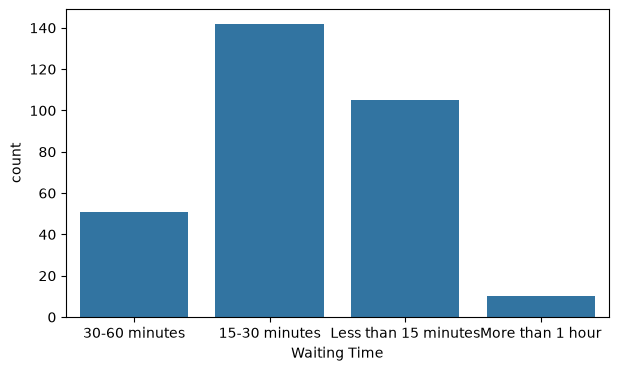

In [22]:
# Waiting time 
plt.figure(figsize=(7,4))
sns.countplot(x="Waiting Time", data=df)
plt.show()

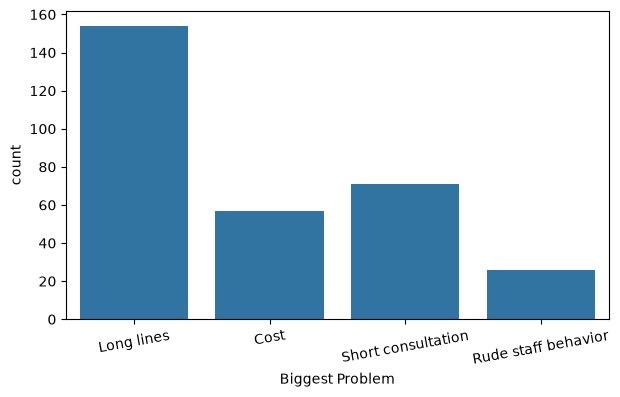

In [23]:
# Most patient waited 15-30 
 
plt.figure(figsize=(7,4))
sns.countplot(x="Biggest Problem", data=df)
plt.xticks(rotation=10)
plt.show() 

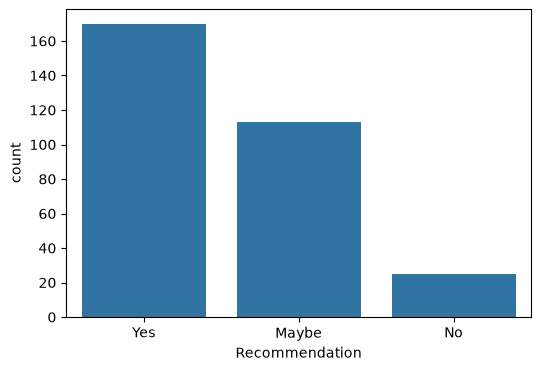

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x="Recommendation", data=df)
plt.show() 


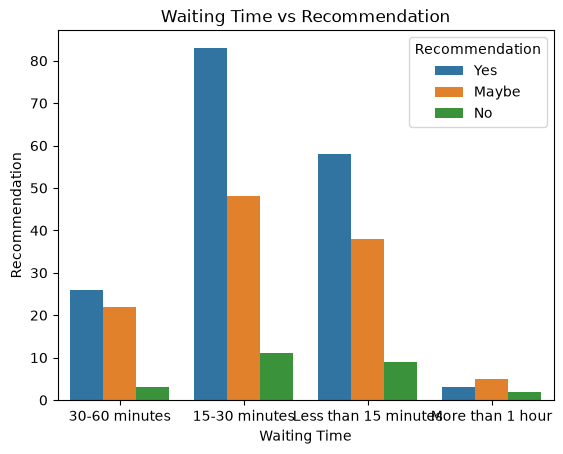

In [25]:
# Bivariate Analysis : Iska mtlb h 2 varaible k beech realtionship dekhna.\
sns.countplot( 
       x= "Waiting Time",
       hue="Recommendation",
       data=df
) 

plt.title("Waiting Time vs Recommendation")
plt.xlabel("Waiting Time")
plt.ylabel("Recommendation")
plt.show()


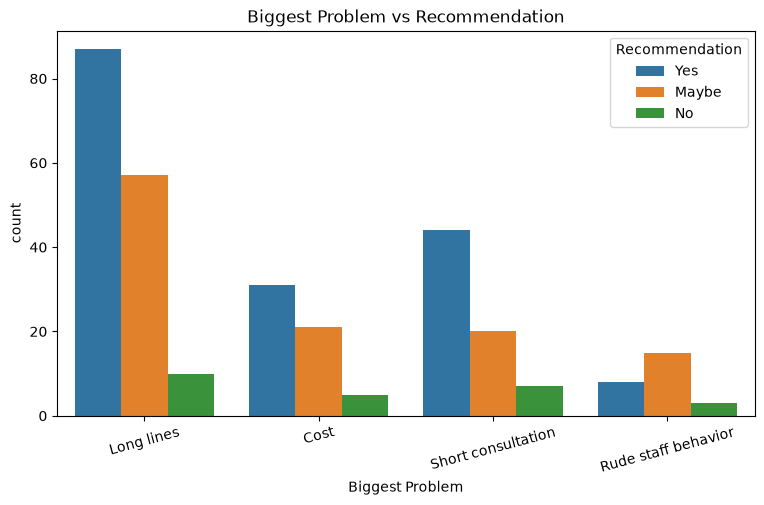

In [26]:

# Biggest Problem Vs Recommendation 
plt.figure(figsize=(9,5))

sns.countplot(
    x="Biggest Problem",
    hue="Recommendation",
    data=df
)

plt.xticks(rotation=15)

plt.title("Biggest Problem vs Recommendation")

plt.show()

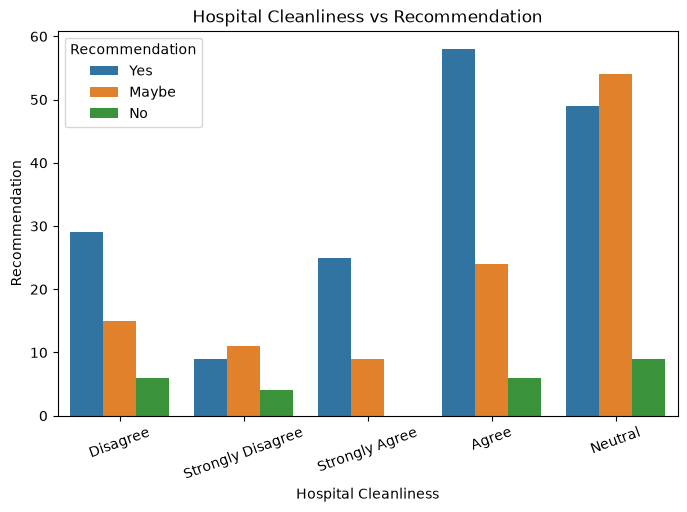

In [28]:
# Hospital Cleanliness vs Recommendation
plt.figure(figsize=(8,5))
sns.countplot(
    x="Hospital Cleanliness",
    hue="Recommendation",
    data=df
)
plt.xticks(rotation=20)
plt.title("Hospital Cleanliness vs Recommendation")
plt.ylabel("Recommendation")
plt.show()

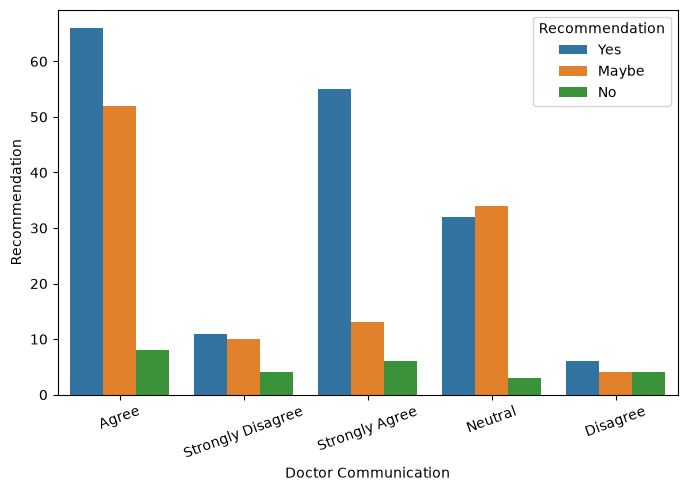

In [29]:
#Doctor Communication vs Recommendation
plt.figure(figsize=(8,5))
sns.countplot(
    x="Doctor Communication",
    hue="Recommendation",
    data=df
)
plt.xticks(rotation=20)
plt.ylabel("Recommendation")
plt.show()


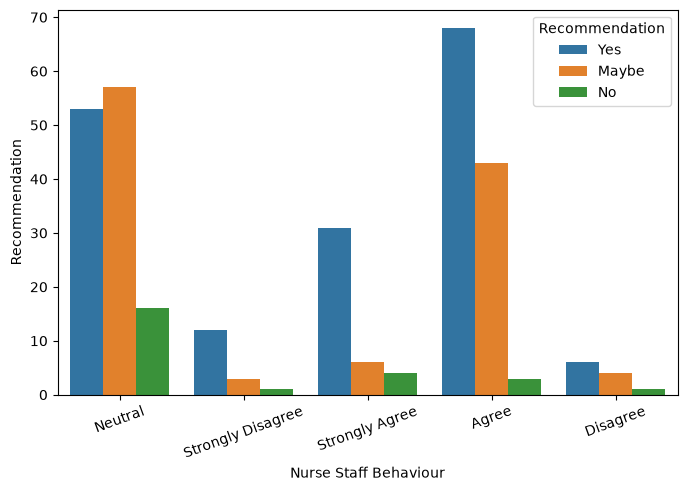

In [30]:
# Nurse Behaviour vs Recommendation

plt.figure(figsize=(8,5))

sns.countplot(
    x="Nurse Staff Behaviour",
    hue="Recommendation",
    data=df
)
plt.xticks(rotation=20)
plt.ylabel("Recommendation")
plt.show()

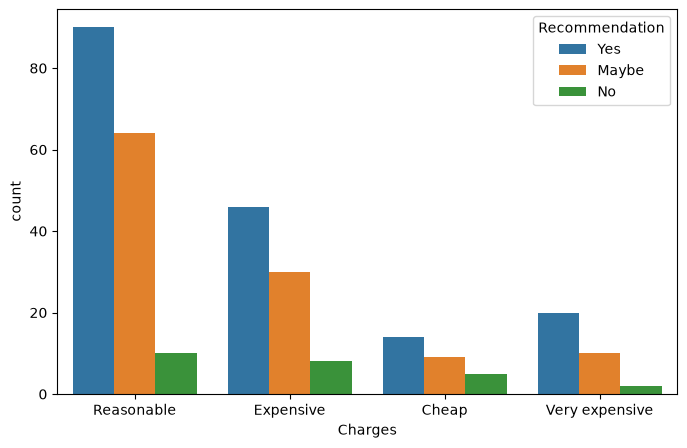

In [31]:
# Charges Vs Recommendation

plt.figure(figsize=(8,5))

sns.countplot(
    x="Charges",
    hue="Recommendation",
    data=df
)
plt.show()


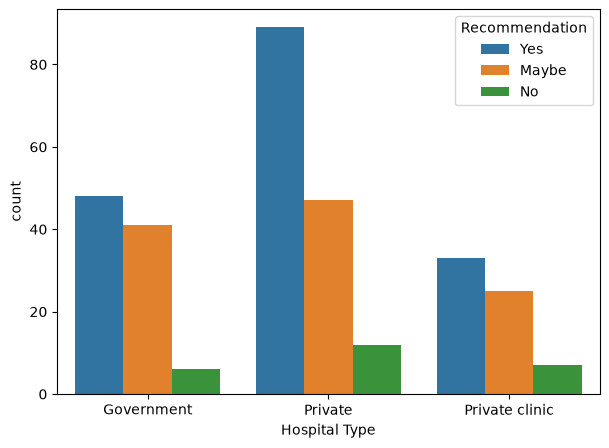

In [32]:
# Hospital Type vs Recommendation
plt.figure(figsize=(7,5))
sns.countplot(
    x="Hospital Type",
    hue="Recommendation",
    data=df
)
plt.show()


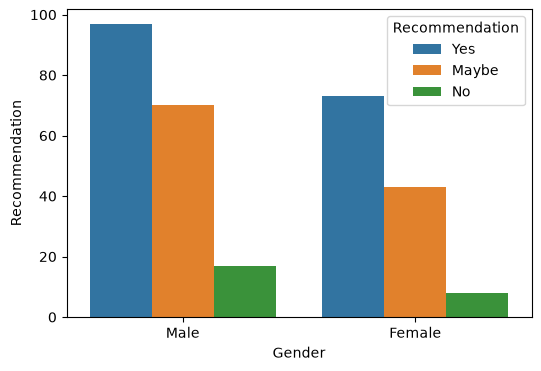

In [33]:
# Gender vs Recommendation
plt.figure(figsize=(6,4))

sns.countplot(
    x="Gender",
    hue="Recommendation",
    data=df
)
plt.ylabel("Recommendation")
plt.show()

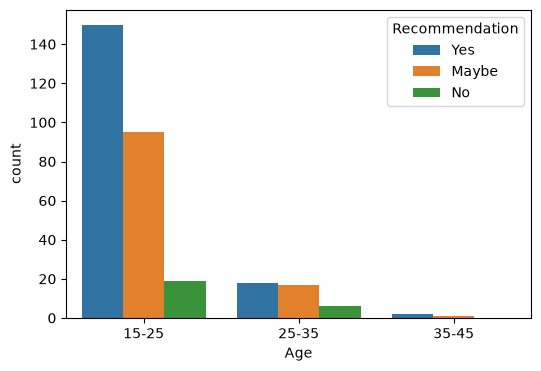

In [34]:
# Age vs Recommendation
plt.figure(figsize=(6,4))

sns.countplot(
    x="Age",
    hue="Recommendation",
    data=df
)
plt.show()

# Data Pre-Processing : preprocessing contain Rawdatacollection, cleaning, Nullvalue, outliers, duplicates, missingsvalues, encoding, train-test . 

In [11]:
# Encoding categorical variables
for col in df.select_dtypes(include=["object", "string"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
print(df.head())  
print(df.dtypes)   

   Gender  Age  Hospital Type  Visit Type  Waiting Time  \
0       1    0              0           1             1   
1       0    0              1           3             0   
2       0    0              2           3             2   
3       1    1              2           3             0   
4       1    0              2           3             0   

   Nurse Staff Behaviour  Doctor Communication  Hospital Cleanliness  \
0                      2                     0                     1   
1                      4                     4                     4   
2                      3                     3                     3   
3                      0                     3                     3   
4                      0                     3                     0   

   Overall Satisfaction  Return Intention  ...  Waiting Area Facilities  \
0                     4                 3  ...                        1   
1                     3                 3  ...                

In [12]:
# Saving encoded dataset
df.to_csv("encoded_healthcare_data.csv", index=False)

# After model building to check Encoding 

In [13]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print()

Gender
[1 0]

Age
[0 1 2]

Hospital Type
[0 1 2]

Visit Type
[1 3 0 2]

Waiting Time
[1 0 2 3]

Nurse Staff Behaviour
[2 4 3 0 1]

Doctor Communication
[0 4 3 2 1]

Hospital Cleanliness
[1 4 3 0 2]

Overall Satisfaction
[4 3 1 5 2]

Return Intention
[3 2 1]

Biggest Problem
[1 0 3 2]

Recommendation
[2 0 1]

Treatment Quality
[2 4 5 3 1]

Waiting Area Facilities
[1 2 3 0 4]

Respect Privacy
[2 0 3 1 4]

Medicine Explanation
[0 3 2 1 4]

Charges
[2 1 0 3]

Occupation
[5 3 6 4 0 1 2]

Age1
[65 30]

Nurse Staff Behaviour Score
[3 1 5 4 2]

Hospital Cleanliness Score
[2 1 5 4 3]

Overall_satisfaction_Avergae
[3.03846154]

Waiting Time Number
[45 22 10 75]



In [14]:
# ===========================================
# CHECK ORIGINAL ENCODING MAPPING
# ===========================================

original_df = pd.read_csv(
    "Dataset/ORIGINAL_HealthcareServiceQuality_Merged.csv"
)

categorical_columns = original_df.select_dtypes(
    include=["object", "string"]
).columns

for col in categorical_columns:

    encoder = LabelEncoder()

    encoded_values = encoder.fit_transform(
        original_df[col].astype(str)
    )

    print("\n==============================")
    print(col)
    print("==============================")

    for category, number in zip(
        encoder.classes_,
        range(len(encoder.classes_))
    ):
        print(category, "→", number)


Gender
Female → 0
Male → 1

Age
15-25 → 0
25-35 → 1
35-45 → 2

Hospital Type
Government → 0
Private → 1
Private clinic → 2

Visit Type
Emergency → 0
Follow-up/Routine Checkup → 1
In-Patient (Admitted/Hospitalized) → 2
OPD (Doctor Consultation ) → 3

Waiting Time
15-30 minutes → 0
30-60 minutes → 1
Less than 15 minutes → 2
More than 1 hour → 3

Nurse Staff Behaviour
Agree → 0
Disagree → 1
Neutral → 2
Strongly Agree → 3
Strongly Disagree → 4

Doctor Communication
Agree → 0
Disagree → 1
Neutral → 2
Strongly Agree → 3
Strongly Disagree → 4

Hospital Cleanliness
Agree → 0
Disagree → 1
Neutral → 2
Strongly Agree → 3
Strongly Disagree → 4

Biggest Problem
Cost → 0
Long lines → 1
Rude staff behavior → 2
Short consultation → 3
nan → 4

Recommendation
Maybe → 0
No → 1
Yes → 2

Waiting Area Facilities
Agree → 0
Disagree → 1
Neutral → 2
Strongly Agree → 3
Strongly Disagree → 4

Respect Privacy
Agree → 0
Disagree → 1
Neutral → 2
Strongly Agree → 3
Strongly Disagree → 4

Medicine Explanation
Agree 

In [16]:
for col in categorical_columns:
    encoder = LabelEncoder()

    values = original_df[col].astype(str)
    encoder.fit(values)

    print(f"\n{col}:")
    print(dict(zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    )))


Gender:
{'Female': np.int64(0), 'Male': np.int64(1)}

Age:
{'15-25': np.int64(0), '25-35': np.int64(1), '35-45': np.int64(2)}

Hospital Type:
{'Government': np.int64(0), 'Private': np.int64(1), 'Private clinic': np.int64(2)}

Visit Type:
{'Emergency': np.int64(0), 'Follow-up/Routine Checkup': np.int64(1), 'In-Patient (Admitted/Hospitalized)': np.int64(2), 'OPD (Doctor Consultation )': np.int64(3)}

Waiting Time:
{'15-30 minutes': np.int64(0), '30-60 minutes': np.int64(1), 'Less than 15 minutes': np.int64(2), 'More than 1 hour': np.int64(3)}

Nurse Staff Behaviour:
{'Agree': np.int64(0), 'Disagree': np.int64(1), 'Neutral': np.int64(2), 'Strongly Agree': np.int64(3), 'Strongly Disagree': np.int64(4)}

Doctor Communication:
{'Agree': np.int64(0), 'Disagree': np.int64(1), 'Neutral': np.int64(2), 'Strongly Agree': np.int64(3), 'Strongly Disagree': np.int64(4)}

Hospital Cleanliness:
{'Agree': np.int64(0), 'Disagree': np.int64(1), 'Neutral': np.int64(2), 'Strongly Agree': np.int64(3), 'Stro

In [17]:
# Check remaining categorical mappings

columns_to_check = [
    "Biggest Problem",
    "Waiting Area Facilities",
    "Respect Privacy",
    "Medicine Explanation"
]

for col in columns_to_check:
    encoder = LabelEncoder()

    values = original_df[col].astype(str)
    encoder.fit(values)

    print("\n==============================")
    print(col)
    print("==============================")

    for category, number in zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    ):
        print(f"{category} → {number}")


Biggest Problem
Cost → 0
Long lines → 1
Rude staff behavior → 2
Short consultation → 3
nan → 4

Waiting Area Facilities
Agree → 0
Disagree → 1
Neutral → 2
Strongly Agree → 3
Strongly Disagree → 4

Respect Privacy
Agree → 0
Disagree → 1
Neutral → 2
Strongly Agree → 3
Strongly Disagree → 4

Medicine Explanation
Agree → 0
Disagree → 1
Neutral → 2
Strongly Agree → 3
Strongly Disagree → 4


In [15]:
# ===========================================
# CHECK TARGET MAPPING
# ===========================================

target_encoder = LabelEncoder()

target_encoder.fit(
    original_df["Recommendation"].astype(str)
)

print("Recommendation Mapping:")

for category, number in zip(
    target_encoder.classes_,
    range(len(target_encoder.classes_))
):
    print(category, "→", number)

Recommendation Mapping:
Maybe → 0
No → 1
Yes → 2


# Feature Selection

In [13]:
# ===========================================
# FEATURE SELECTION / TARGET VARIABLE
# ===========================================

# Remove features that we decided not to use
df.drop(
    ["Age", "Overall_satisfaction_Avergae"],
    axis=1,
    inplace=True
)

# Target variable
y = df["Recommendation"]

# Feature variables
X = df.drop("Recommendation", axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (308, 20)
y shape: (308,)


# Train Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
  X, 
  y, 
  test_size= 0.2, 
  random_state = 42
)

# Feature Scaling is not important for every dataset 

In [15]:
print("X_train.shape", X_train.shape)    # Train data = 80% of 309 = 246
print("X_test.shape:",X_test.shape)     # Test data = 20% of 309 = 62

print(X_train.dtypes) 

X_train.shape (246, 20)
X_test.shape: (62, 20)
Gender                         int64
Hospital Type                  int64
Visit Type                     int64
Waiting Time                   int64
Nurse Staff Behaviour          int64
Doctor Communication           int64
Hospital Cleanliness           int64
Overall Satisfaction           int64
Return Intention               int64
Biggest Problem                int64
Treatment Quality              int64
Waiting Area Facilities        int64
Respect Privacy                int64
Medicine Explanation           int64
Charges                        int64
Occupation                     int64
Age1                           int64
Nurse Staff Behaviour Score    int64
Hospital Cleanliness Score     int64
Waiting Time Number            int64
dtype: object


In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1 Logistic Regression

In [17]:

# MODEL 1 : Logistic Regression


model = LogisticRegression(max_iter=100)

# Train Model 
model.fit(X_train_scaled, y_train)  # ye ine model ki training k liye h   "Question" 
y_pred = model.predict(X_test_scaled)


# Accuracy 
accuracy = accuracy_score(y_test, y_pred) # 1st accuracy = 51%

print("Accuracy:", accuracy)   

# Confusion metrics
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Classification Report
print(classification_report(y_test, y_pred))

Accuracy: 0.532258064516129
[[11  0 18]
 [ 1  1  0]
 [ 8  2 21]]
              precision    recall  f1-score   support

           0       0.55      0.38      0.45        29
           1       0.33      0.50      0.40         2
           2       0.54      0.68      0.60        31

    accuracy                           0.53        62
   macro avg       0.47      0.52      0.48        62
weighted avg       0.54      0.53      0.52        62



# ===========================================
# MODEL 2 : Decision Tree  
# ===========================================


In [18]:
dt_model = DecisionTreeClassifier(random_state=42) # Create Model
dt_model.fit(X_train, y_train)                     # Train model 
y_pred_dt = dt_model.predict(X_test)               # prediction

# Accuracy of DT 
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(" Decision Tree Accuracy :", dt_accuracy)

# Confusion Matrix
print(classification_report(y_test, y_pred_dt))



 Decision Tree Accuracy : 0.6451612903225806
              precision    recall  f1-score   support

           0       0.74      0.59      0.65        29
           1       0.25      1.00      0.40         2
           2       0.68      0.68      0.68        31

    accuracy                           0.65        62
   macro avg       0.56      0.75      0.58        62
weighted avg       0.69      0.65      0.66        62




# ===========================================
# MODEL 3 : KNN "KNeighbours"   
# ===========================================

In [19]:
knn_model = KNeighborsClassifier(n_neighbors=5) # createModel

knn_model.fit(X_train_scaled, y_train) # trainModel
y_pred_knn = knn_model.predict(X_test_scaled) # prediction 

# Accuracy 
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy : ", knn_accuracy)

# Confusion Matrix 
print(confusion_matrix(y_test, y_pred_knn))

# Classificatin Report 
print(classification_report(y_test, y_pred_knn))



KNN Accuracy :  0.5806451612903226
[[17  1 11]
 [ 2  0  0]
 [11  1 19]]
              precision    recall  f1-score   support

           0       0.57      0.59      0.58        29
           1       0.00      0.00      0.00         2
           2       0.63      0.61      0.62        31

    accuracy                           0.58        62
   macro avg       0.40      0.40      0.40        62
weighted avg       0.58      0.58      0.58        62



# ===========================================
# MODEL 4 : "SVM" Support Vectore Machine   
# ===========================================

In [20]:


svm_model = SVC(kernel="rbf", random_state=42) # Create model 

svm_model.fit(X_train_scaled, y_train) # Train Model
y_pred_svm = svm_model.predict(X_test_scaled) # Prediction 

svm_accuracy = accuracy_score(y_test, y_pred_svm) #Acccuracy
print('SVM Accuracy:', svm_accuracy)

#Confusion Matrix 
print(confusion_matrix(y_test, y_pred_svm))

#Classification Report
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.6451612903225806
[[14  0 15]
 [ 1  1  0]
 [ 6  0 25]]
              precision    recall  f1-score   support

           0       0.67      0.48      0.56        29
           1       1.00      0.50      0.67         2
           2       0.62      0.81      0.70        31

    accuracy                           0.65        62
   macro avg       0.76      0.60      0.64        62
weighted avg       0.66      0.65      0.64        62



# ===========================================
# MODEL 5 : Random Forest   
# ===========================================

In [21]:
# ===========================================
# RANDOM FOREST - MANUAL TUNING
# ===========================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7419354838709677
Confusion Matrix:
[[14  0 15]
 [ 0  2  0]
 [ 1  0 30]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.48      0.64        29
           1       1.00      1.00      1.00         2
           2       0.67      0.97      0.79        31

    accuracy                           0.74        62
   macro avg       0.87      0.82      0.81        62
weighted avg       0.80      0.74      0.72        62



# ===========================================
# HYPERPARAMETER TUNING PROPERLY OF DATASET
# ===========================================

In [23]:
print("X columns:", len(X.columns))
print("Feature importances:", len(rf_model.feature_importances_))
print(X.columns.tolist())

X columns: 20
Feature importances: 20
['Gender', 'Hospital Type', 'Visit Type', 'Waiting Time', 'Nurse Staff Behaviour', 'Doctor Communication', 'Hospital Cleanliness', 'Overall Satisfaction', 'Return Intention', 'Biggest Problem', 'Treatment Quality', 'Waiting Area Facilities', 'Respect Privacy', 'Medicine Explanation', 'Charges', 'Occupation', 'Age1', 'Nurse Staff Behaviour Score', 'Hospital Cleanliness Score', 'Waiting Time Number']


In [24]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                        Feature  Importance
8              Return Intention    0.108598
7          Overall Satisfaction    0.091777
10            Treatment Quality    0.060997
4         Nurse Staff Behaviour    0.056604
11      Waiting Area Facilities    0.055771
5          Doctor Communication    0.055749
6          Hospital Cleanliness    0.053807
12              Respect Privacy    0.053378
19          Waiting Time Number    0.048580
18   Hospital Cleanliness Score    0.046129
17  Nurse Staff Behaviour Score    0.044821
13         Medicine Explanation    0.042955
9               Biggest Problem    0.042857
14                      Charges    0.041410
2                    Visit Type    0.041060
3                  Waiting Time    0.038892
15                   Occupation    0.038168
1                 Hospital Type    0.038017
0                        Gender    0.029869
16                         Age1    0.010560


# Drop two features
 


# ===========================================
# GRID SearchCV : for best parameter value to be searched
   Tum mujhe saare possible parameters dedo m tumhe saare best parameter value de dunga 

In [28]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}  # this code tries 108 combinations


In [29]:
# Create GridSearchCV

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),   # Base Model
    param_grid=param_grid,     # Kis-kis value ko test krna h
    cv=5,                          # 5 Fold Cross validation 
    scoring="accuracy",
    n_jobs =-1                    # Accuracy ke basis pr best model
)

 # train GridSearch
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

# Accuracy 
print("Best CV Accuracy:", grid_search.best_score_)
print(grid_search.best_score_)



Best Parameters:
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best CV Accuracy: 0.6990204081632653
0.6990204081632653



# BEST MODEL FROM GRID SEARCH  isko rakhna h 


In [30]:
# Model
best_rf = grid_search.best_estimator_

# Prediction
y_pred_best = best_rf.predict(X_test)

# Final Accuracy 
print("Final Accuracy :", accuracy_score(y_test, y_pred_best))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred_best))

# Classification Report
print(classification_report(y_test, y_pred_best))


Final Accuracy : 0.7419354838709677
[[14  0 15]
 [ 0  2  0]
 [ 1  0 30]]
              precision    recall  f1-score   support

           0       0.93      0.48      0.64        29
           1       1.00      1.00      1.00         2
           2       0.67      0.97      0.79        31

    accuracy                           0.74        62
   macro avg       0.87      0.82      0.81        62
weighted avg       0.80      0.74      0.72        62



In [31]:
# ===========================================
# SMOTE EXPERIMENT
# ===========================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Recommendation
2    139
0     84
1     23
Name: count, dtype: int64

After SMOTE:
Recommendation
0    139
2    139
1    139
Name: count, dtype: int64


In [34]:
# ===========================================
# RANDOM FOREST WITH SMOTE
# ===========================================

rf_smote = RandomForestClassifier(
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_test)

# Accuracy
print("SMOTE Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_smote))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

SMOTE Random Forest Accuracy:
0.6935483870967742

Confusion Matrix:
[[15  1 13]
 [ 0  2  0]
 [ 2  3 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.52      0.65        29
           1       0.33      1.00      0.50         2
           2       0.67      0.84      0.74        31

    accuracy                           0.69        62
   macro avg       0.63      0.79      0.63        62
weighted avg       0.76      0.69      0.69        62



Above random forest with SMOTE decreases the performance of the model . 

# Save Final Model

In [35]:
# ===========================================
# SAVE FINAL MODEL
# ===========================================

final_model = grid_search.best_estimator_

joblib.dump(
    final_model,
    "healthcare_model.pkl"
)

print("Final Model Saved Successfully!")

Final Model Saved Successfully!


# Interpretation 
                 : Final model = Without SMOTE GridSerach Random Forest. 